In [1]:
import ast
import os
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

def extract_genus_name(x):
    try:
        genus_dict = ast.literal_eval(x)
        return genus_dict.get('name', None)
    except:
        return None

os.chdir('/active-data/analysis_results/chr_pla')
all_data = pd.read_csv('genome_chr-pla_statistics.csv')
all_data['genus_clean'] = all_data['genus'].apply(extract_genus_name)
counts = all_data['genus_clean'].value_counts()
keep_genus = counts[counts >= 400].index.to_list()
print(keep_genus)

['Escherichia', 'Klebsiella', 'Staphylococcus', 'Pseudomonas', 'Bacillus', 'Salmonella', 'Streptococcus', 'Streptomyces', 'Acinetobacter', 'Enterococcus', 'Bordetella', 'Enterobacter', 'Xanthomonas', 'Campylobacter', 'Vibrio', 'Mycobacterium', 'Corynebacterium', 'Burkholderia', 'Listeria', 'Citrobacter', 'Helicobacter']


In [2]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"
bfont_path = "/usr/share/fonts/myFonts/arialbd.ttf"

fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_prop_7 = FontProperties(fname=font_path, size=7)
font_name = font_prop.get_name()
ifont_prop = FontProperties(fname=ifont_path)
ifont_prop_7 = FontProperties(fname=ifont_path, size=7)
bfont_prop = FontProperties(fname=bfont_path)

plt.rcParams["font.family"] = [font_name]
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
})

label = "pident_90"
base_folder = f'/active-data/analysis_results/chr_pla/genus'

In [3]:
import numpy as np
np.random.seed(42)

def draw_pseudogene_data(keep_genus, ax, label):
    # label = 'pident_90'
    all_data = []
    for genus_name in keep_genus:
        folder = f'{base_folder}/statistics_records/{genus_name}'
        os.chdir(folder)
        
        fraction_data = pd.read_csv('replicon-plasmid_fraction-self_bitscore_statistics.csv')
        pseudogene_data = pd.read_csv('pseudogene_statistics.tsv', sep='\t')
        
        pseudogene_data = pseudogene_data[pseudogene_data['CDSs (total)'] > 0].copy()
        pseudogene_data['Pseudogene Percentage (%)'] = (
            pseudogene_data['CDSs (without protein, Pseudo Genes)'] / pseudogene_data['CDSs (total)']
        ) * 100
        pseudogene_data = pseudogene_data.rename(columns={'contig': 'accession'})
        
        merge_data = pd.merge(
            pseudogene_data,
            fraction_data[['accession', f'category-{label}']],
            on='accession', how='left'
        )

        chr_frag_data = pd.read_csv(f'{base_folder}/kmer_chr_frag_samples/{genus_name}/chromosome_fragment_data.tsv', sep='\t')
        chr_frag_data = chr_frag_data[chr_frag_data['CDSs (total)'] > 0]
        chr_frag_data['Pseudogene Percentage (%)'] = (chr_frag_data['CDSs (without protein, Pseudo Genes)'] / chr_frag_data['CDSs (total)']) * 100
        chr_frag_data[f'category-{label}'] = 'chromosome fragment'
        chr_frag_data = chr_frag_data.rename(columns={'sequence': 'accession'})
        chr_frag_data = chr_frag_data[merge_data.columns]
        merge_data = pd.concat([merge_data, chr_frag_data], ignore_index=True)
        
        merge_data['genus'] = genus_name
        all_data.append(merge_data)
    
    df_all = pd.concat(all_data, ignore_index=True).dropna(subset=[f'category-{label}'])
    
    genus_list = df_all['genus'].unique()
    categories = ['typical plasmid', 'intermediate replicon', 'chromosome fragment', 'typical chromosome']
    colors = [
        plt.cm.tab10(0),
        plt.cm.tab10(2),
        plt.cm.tab10(1),
        plt.cm.tab10(3)
    ]
    n_cats = len(categories)
    
    total_width = 0.8
    single_genus_width = total_width / n_cats
    genus_positions = {g: i for i, g in enumerate(genus_list)}
    x_coords = []
    x_labels = []
    
    for g_idx, genus in enumerate(genus_list):
        df_g = df_all[df_all['genus'] == genus]
        
        for c_idx, cat in enumerate(categories):
            df_sub = df_g[df_g[f'category-{label}'] == cat]
            if df_sub.empty:
                continue
            
            y = df_sub['Pseudogene Percentage (%)'].values
            x_base = g_idx + (c_idx - (n_cats-1)/2) * single_genus_width
            
            parts = ax.violinplot(
                [y], positions=[x_base],
                showmeans=False, showmedians=False, showextrema=False,
                widths=single_genus_width
            )
            for pc in parts['bodies']:
                pc.set_facecolor(colors[c_idx])
                pc.set_edgecolor('black')
                pc.set_alpha(0.4)
    
            median_val = np.mean(y)
            half_w = single_genus_width * 0.35
            ax.plot(
                [x_base - half_w, x_base + half_w],
                [median_val, median_val],
                color='red', linewidth=1
            )
            
            x_jitter = np.random.normal(x_base, single_genus_width*0.1, len(y))
            ax.scatter(x_jitter, y, color=colors[c_idx], s=5, alpha=0.5, edgecolor='k', linewidth=0)
        
        x_coords.append(g_idx)
        x_labels.append(genus)
    
    ax.set_xticks(x_coords)
    ax.set_xticklabels(x_labels, rotation=30, ha='right', va='top', rotation_mode='anchor', fontproperties=ifont_prop_7)
    ax.set_ylabel('Pseudogene percentage (%)')
    ax.set_xlim(-0.5, len(genus_list)-0.5)
    ax.set_ylim(-5, 105)
    
    legend_elements = [
        Patch(facecolor=colors[0], label='Typical plasmid'),
        Patch(facecolor=colors[1], label='Intermediate replicon'),
        Patch(facecolor=colors[2], label='Chromosomal fragment'),
        Patch(facecolor=colors[3], label='Typical chromosome'),
        Line2D([], [], color='red', linewidth=1, label='Mean')
    ]
    ax.legend(handles=legend_elements, bbox_to_anchor=(0, 1), loc='lower left', ncol=5)
    
    for i in range(1, len(genus_list)):
        ax.axvline(x=i-0.5, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

In [4]:
def get_all_pcn_data(keep_genus, PCN_target, label):
    all_data = []
    
    for genus_name in keep_genus:
        folder = f'{base_folder}/statistics_records/{genus_name}'
        os.chdir(folder)
        
        fraction_data = pd.read_csv('replicon-plasmid_fraction-self_bitscore_statistics.csv')
        fraction_data["Contig"] = fraction_data["accession"].str.split("-").str[1]
        
        fraction_data = fraction_data[fraction_data[f'category-{label}'].isin([
            'typical plasmid', 
            'intermediate replicon'
        ])]
        
        merged = pd.merge(
            fraction_data[['Contig', f'category-{label}']],
            PCN_target[['Contig', 'PCN']],
            on='Contig', how='left'
        )
        merged = merged.dropna(subset=['PCN'])
        merged['genus'] = genus_name
        
        if not merged.empty:
            all_data.append(merged)
    
    if not all_data:
        raise ValueError("No valid data!")
    
    df_all = pd.concat(all_data, ignore_index=True)
    return df_all

def plot_pcn_on_ax(ax, data, label):
    categories = ['typical plasmid', 'intermediate replicon']
    
    colors = [plt.cm.tab10(0), plt.cm.tab10(2),]
    genus_list = data['genus'].unique()
    n_cats = len(categories)
    
    total_width = 0.7
    single_width = total_width / n_cats

    for g_idx, genus in enumerate(genus_list):
        df_g = data[data['genus'] == genus]
        
        for c_idx, cat in enumerate(categories):
            df_sub = df_g[df_g[f'category-{label}'] == cat]
            if df_sub.empty:
                continue
            
            pcn_raw = df_sub['PCN'].values
            y = np.log10(pcn_raw)
            x_base = g_idx + (c_idx - (n_cats - 1) / 2) * single_width

            parts = ax.violinplot(
                [y], positions=[x_base],
                showmeans=False, showmedians=False, showextrema=False,
                widths=single_width * 0.9
            )
            for pc in parts['bodies']:
                pc.set_facecolor(colors[c_idx])
                pc.set_edgecolor('black')
                pc.set_alpha(0.4)

            mean_val = np.mean(y)
            half_w = single_width * 0.35
            ax.plot([x_base - half_w, x_base + half_w],
                    [mean_val, mean_val], color='red', lw=1.5)

            x_jitter = np.random.normal(x_base, single_width * 0.08, len(y))
            ax.scatter(x_jitter, y, color=colors[c_idx],
                       s=3, alpha=0.6, edgecolor='k', linewidth=0)

    ax.set_xticks(np.arange(len(genus_list)))
    ax.set_xticklabels(genus_list, rotation=30, ha='right', va='top', rotation_mode='anchor', fontproperties=ifont_prop_7)
    ax.set_ylabel(r'log$_{10}$(Copy number)')
    ax.set_xlim(-0.5, len(genus_list) - 0.5)

    for i in range(1, len(genus_list)):
        ax.axvline(x=i - 0.5, color='gray', lw=0.5, alpha=0.6, linestyle='--')

    legend_elements = [
        Patch(facecolor=colors[0], label='Typical plasmid'),
        Patch(facecolor=colors[1], label='Intermediate replicon'),
        Line2D([], [], color='red', lw=1.5, label='Mean')
    ]
    ax.legend(handles=legend_elements, bbox_to_anchor=(0, 1), loc='lower left', ncol=3)

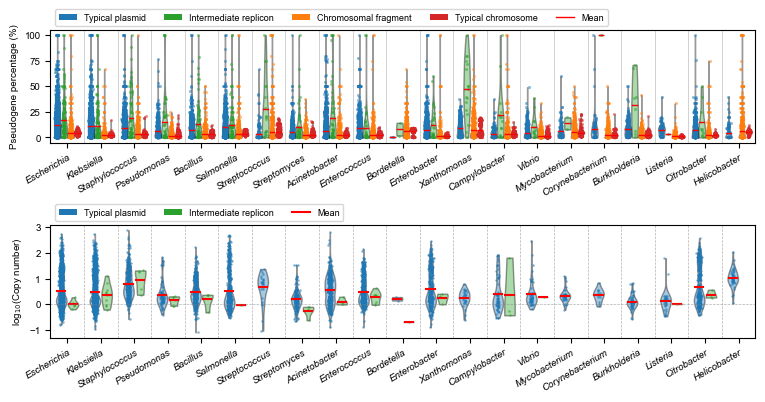

In [5]:
fig = plt.figure(figsize=(7.5, 7.5))

# Pseudogene_figure
Pseudo_x_site = 0
Pseudo_y_site = 1 - (0.2 + 0.0)
ax_pseudogene = fig.add_axes([Pseudo_x_site+0.06, Pseudo_y_site, 1-0.06, 0.15])

draw_pseudogene_data(keep_genus, ax_pseudogene, label)

article_id = ['PMID40603865', 'PMID40603299']
PCN1 = pd.read_csv(f'/active-data/analysis_results/chr_pla/reference_data/{article_id[0]}/Fig1BC-Source-Data.csv')
PCN1 = PCN1.rename(columns={'SeqID': 'Contig', 'PIRACopyNumber': 'PCN'})
PCN2 = pd.read_excel(f'/active-data/analysis_results/chr_pla/reference_data/{article_id[1]}/41467_2025_61202_MOESM3_ESM.xlsx', sheet_name=1)

data = get_all_pcn_data(
    keep_genus=keep_genus,
    PCN_target=PCN1,
    label=label
)

PCN_x_site = 0
PCN_y_site = Pseudo_y_site - (0.2 + 0.06)
ax_copynumber = fig.add_axes([PCN_x_site+0.06, PCN_y_site, 1-0.06, 0.15])
plot_pcn_on_ax(ax_copynumber, data, label=label)
ax_copynumber.axhline(0, color='gray', lw=0.5, alpha=0.6, linestyle='--')

figure_fold = f'{base_folder}/figures'
os.chdir(figure_fold)
plt.savefig(f"S_all_genera_pseudogene_and_copy_number.svg", bbox_inches="tight", transparent=True)
plt.savefig(f"S_all_genera_pseudogene_and_copy_number.png", dpi=1000, bbox_inches="tight", transparent=True)

plt.show()